## Final Project Code
### Name: Rachel Ellinger


In [2]:
# Load the TESS dataset
import kagglehub

path = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")

print("Path to dataset files:", path)

/home/rache/miniforge3/envs/cs135_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████| 428M/428M [01:14<00:00, 5.99MB/s]

Extracting files...


Path to dataset files: /home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1


In [4]:
# Verify download
import os

folders = os.listdir(path)
print(f"Found {len(folders)} folders.")

print("Folder names:", folders)

Found 2 folders.
Folder names: ['TESS Toronto emotional speech set data', 'tess toronto emotional speech set data']


In [12]:
base_path = "/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data"
subfolders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))] # if-block is additional safety check to look only at desired directories and avoid other files/metadata
print(f"Total subfolders: {len(subfolders)} subfolders")
print("Subfolder names: ", subfolders)

Total subfolders: 14 subfolders
Subfolder names:  ['YAF_happy', 'OAF_disgust', 'YAF_neutral', 'OAF_neutral', 'OAF_Fear', 'OAF_angry', 'YAF_disgust', 'YAF_angry', 'OAF_Pleasant_surprise', 'YAF_fear', 'OAF_Sad', 'YAF_sad', 'OAF_happy', 'YAF_pleasant_surprised']


In [18]:
# Map folders to speakers (yaf, oaf) and emotions (happy, anger, disgust, fear, pleasant surprise, sad, and neutral)
# Folders are named 'speaker_emotion' and need to be standardized first

import pandas as pd

data_list = []

for folder in subfolders:
    # Standardize to lowercase and split
    parts = folder.lower().split('_')
    
    # Extract the speaker
    speaker = parts[0]
    # Extract and clean the emotion
    raw_emotion = "_".join(parts[1:]) # address split multiple words like "pleasant_surprise"
    # Standardize (P/p)leasant_surprise(d)
    if 'pleasant' in raw_emotion:
        emotion = 'pleasant_surprise'
    else:
        emotion = raw_emotion
    # Confirm successfully standardized the dataset labels
    print(f"Original: {folder} -> Speaker: {speaker}, Emotion: {emotion}")
    
    # Append the path, speaker, and emotion as an object in the data_list array
    folder_path = os.path.join(base_path, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            data_list.append({
                'path': os.path.join(folder_path, file),
                'speaker': speaker,
                'emotion': emotion
            })

# Convert the array to pandas DataFrame
df = pd.DataFrame(data_list)
pd.set_option('display.max_colwidth', None) # prevent from getting cut off when I print
print(f"Total files: {len(df)}") # should be 7 emotions x 2 speakers x 200 .wav files per emotion = 2800 total files
df.head()

Original: YAF_happy -> Speaker: yaf, Emotion: happy
Original: OAF_disgust -> Speaker: oaf, Emotion: disgust
Original: YAF_neutral -> Speaker: yaf, Emotion: neutral
Original: OAF_neutral -> Speaker: oaf, Emotion: neutral
Original: OAF_Fear -> Speaker: oaf, Emotion: fear
Original: OAF_angry -> Speaker: oaf, Emotion: angry
Original: YAF_disgust -> Speaker: yaf, Emotion: disgust
Original: YAF_angry -> Speaker: yaf, Emotion: angry
Original: OAF_Pleasant_surprise -> Speaker: oaf, Emotion: pleasant_surprise
Original: YAF_fear -> Speaker: yaf, Emotion: fear
Original: OAF_Sad -> Speaker: oaf, Emotion: sad
Original: YAF_sad -> Speaker: yaf, Emotion: sad
Original: OAF_happy -> Speaker: oaf, Emotion: happy
Original: YAF_pleasant_surprised -> Speaker: yaf, Emotion: pleasant_surprise
Total files: 2800


,path,speaker,emotion
0,/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_happy/YAF_dip_happy.wav,yaf,happy
1,/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_happy/YAF_door_happy.wav,yaf,happy
2,/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_happy/YAF_hall_happy.wav,yaf,happy
3,/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_happy/YAF_mouse_happy.wav,yaf,happy
4,/home/rache/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1/TESS Toronto emotional speech set data/YAF_happy/YAF_dime_happy.wav,yaf,happy


In [3]:
# Additional checks on Dataframe set up
print(df['speaker'].unique())
print(df['emotion'].unique())

['yaf' 'oaf']
['happy' 'disgust' 'neutral' 'fear' 'angry' 'pleasant_surprise' 'sad']


In [23]:
# Save DataFrame to file
df.to_csv('speaker_emotion_data.csv', index=False)

In [3]:
# Reload data after kernel times out
import os
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('speaker_emotion_data.csv')

# Load other libraries used repeatedly across all models
import librosa
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report

In [6]:
sns.set_palette("colorblind")

## Approach 1 MFCCs (Mean & Standard Deviation) + Support Vector Machine

In [4]:
import librosa

def extract_audio_features(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None) # sampling rate = None to preserve original file
    
    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
    # Calculate mean and standard deviation from the 20 mfcc coefficients retained
    # Note: mfccs.T to transpose (n_mfcc, time_frame) into (time_frame, n_mfcc) for numpy
    # Note: axis=0 to collapse column-wise
    mfccs_mean = np.mean(mfccs.T, axis=0)
    mfccs_std = np.std(mfccs.T, axis=0)
    
    # Concatenate info 
    feature_vector = np.hstack((mfccs_mean, mfccs_std))
    
    return feature_vector

In [5]:
# Extract the features from the audio data

X = []

for path in df['path']:
    features = extract_audio_features(path)
    X.append(features)

# Convert to numpy arrapy
X = np.array(X)
y = df['emotion'].values

# Check shape, should be (2800, 40) because 2800 files (rows) and 40 features (columns) consisting of 20 mean and 20 std values
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (2800, 40)


In [11]:
from sklearn.preprocessing import StandardScaler

# Create indices for the train/test split for generalization (train on oaf, test on yaf)
train_idx = df[df['speaker'] == 'oaf'].index
test_idx = df[df['speaker'] == 'yaf'].index

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

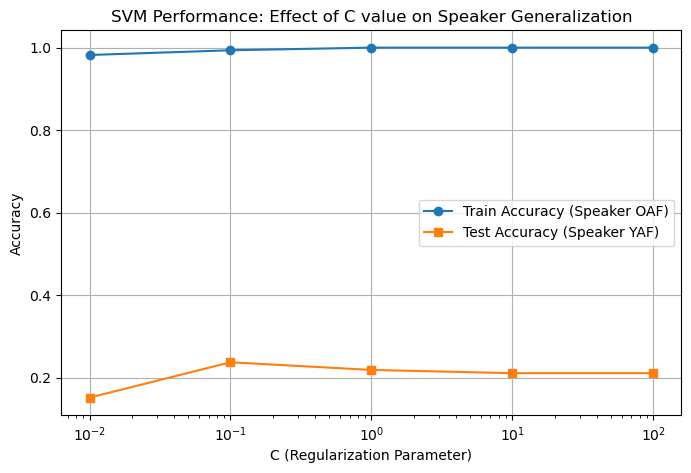

In [16]:
from sklearn.svm import SVC

# Vary the hyperparameter C

c_values = [0.01, 0.1, 1, 10, 100]
train_accuracys = []
test_accuracys = []

for c in c_values:
    model = SVC(kernel='rbf', C=c)
    model.fit(X_train_scaled, y_train)
    
    train_accuracys.append(model.score(X_train_scaled, y_train))
    test_accuracys.append(model.score(X_test_scaled, y_test))

# Plot SVM classifier performance vs hyperparameter for generalization
plt.figure(figsize=(8, 5))
plt.plot(c_values, train_accuracys, label='Train Accuracy (Speaker OAF)', marker='o')
plt.plot(c_values, test_accuracys, label='Test Accuracy (Speaker YAF)', marker='s')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter)')
plt.ylabel('Accuracy')
plt.title('SVM Performance: Effect of C value on Speaker Generalization')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
for train_acc, test_acc, c in zip(train_accuracys, test_accuracys, c_values):
    print(f"Training accuracy: {train_acc: .3f}, Testing accuracy: {test_acc: .3f} for C: {c}")

Training accuracy:  0.982, Testing accuracy:  0.151 for C: 0.01
Training accuracy:  0.994, Testing accuracy:  0.237 for C: 0.1
Training accuracy:  1.000, Testing accuracy:  0.219 for C: 1
Training accuracy:  1.000, Testing accuracy:  0.211 for C: 10
Training accuracy:  1.000, Testing accuracy:  0.211 for C: 100


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Create the best model and display results

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'C': c_values}

grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train.ravel())
print(f"Best CV Accuracy: {grid_search.best_score_}")
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV Accuracy: 0.9964285714285716
Best Parameters: {'C': 1}


In [25]:
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
params = grid_search.cv_results_['params']

for mean, std, param in zip(means, stds, params):
    print(f"Mean Score: {mean:.3f} (+/-{std*2:.03f}) for {param}")

Mean Score: 0.977 (+/-0.017) for {'C': 0.01}
Mean Score: 0.989 (+/-0.009) for {'C': 0.1}
Mean Score: 0.996 (+/-0.005) for {'C': 1}
Mean Score: 0.996 (+/-0.005) for {'C': 10}
Mean Score: 0.996 (+/-0.005) for {'C': 100}


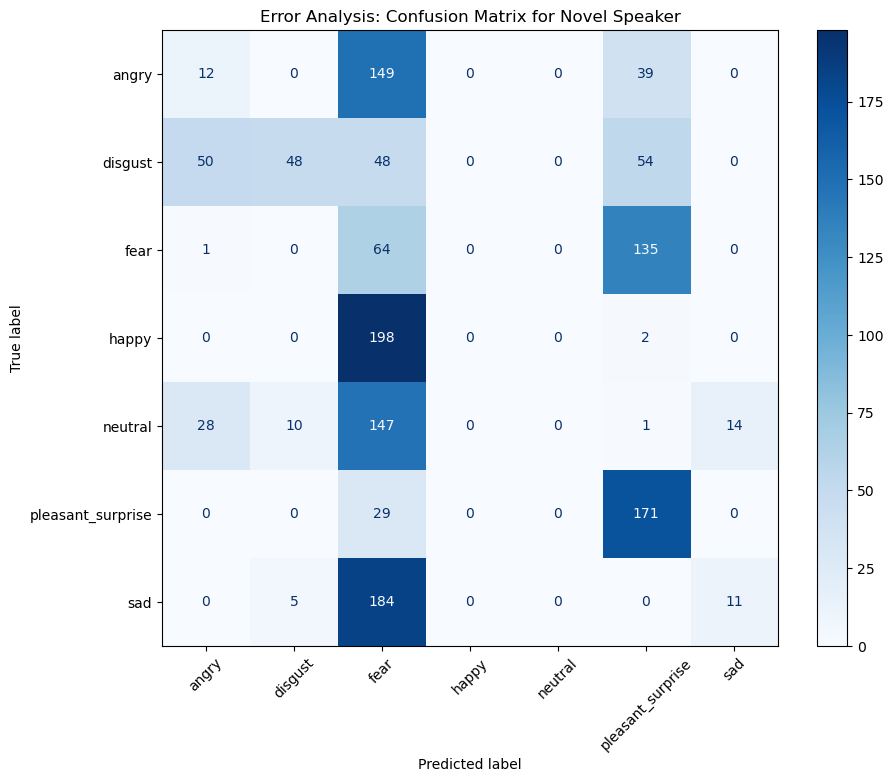

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the best C 
best_model = SVC(kernel='rbf', C=1) 
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Plot the error analysis
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Error Analysis: Confusion Matrix for Novel Speaker")
plt.show()

In [82]:
# Error Analysis: Total misclassified
misclassified = np.where(y_test != y_pred)[0]
n_errors = len(misclassified)
print(f"Total misclassified: {n_errors} out of {len(y_test)} ({n_errors/len(y_test) * 100: .3f}%)")

Total misclassified: 1094 out of 1400 ( 78.143%)


In [42]:
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"The test accuracy for a novel speaker is: {balanced_acc: .3f}")
print(f"The error rate on the test data for a novel speaker is: {1-(balanced_acc): .3f}")

from sklearn.metrics import zero_one_loss
print(f"The zero-one loss on the test data for a novel speaker is: {zero_one_loss(y_test, y_pred): .3f}")

The test accuracy for a novel speaker is:  0.219
The error rate on the test data for a novel speaker is:  0.781
The zero-one loss on the test data for a novel speaker is:  0.781


In [87]:
# Error analysis: classification report
from sklearn.metrics import classification_report

print("Classification Report (Approach 1)")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report (Approach 1)
                   precision    recall  f1-score   support

            angry       0.13      0.06      0.08       200
          disgust       0.76      0.24      0.37       200
             fear       0.08      0.32      0.13       200
            happy       0.00      0.00      0.00       200
          neutral       0.00      0.00      0.00       200
pleasant_surprise       0.43      0.85      0.57       200
              sad       0.44      0.06      0.10       200

         accuracy                           0.22      1400
        macro avg       0.26      0.22      0.18      1400
     weighted avg       0.26      0.22      0.18      1400



## Approach 2 Kalman Smoothing of MFCCs & Deltas + Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier
from filterpy.kalman import KalmanFilter
from tqdm import tqdm

# Varying the hyperparameter R
def extract_temporal_audio_with_r_features(file_path, r_value):
    y, sr = librosa.load(file_path, sr=None) # sampling rate = None to preserve original file
    
    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    # Apply Kalman Filter with the specific R value
    for i in range(20):
        kf = KalmanFilter(dim_x=1, dim_z=1)
        kf.x = np.array([[mfccs[i][0]]]) # initial state
        kf.H = np.array([[1.]]) # measurement function
        kf.P *= 10. # covariance matrix
        kf.R = r_value # measurement noise
        kf.Q = 0.1 # process noise
        
        smoothed, _, _, _ = kf.batch_filter(mfccs[i])
        mfccs[i] = smoothed.flatten()
        
    # Extract Deltas
    deltas = librosa.feature.delta(mfccs)
    
    # Concatenate info (20 mean, 20 std for MFCCs & 20 mean, 20 std for Deltas)
    feature_vector = np.hstack((
        np.mean(mfccs.T, axis=0), np.std(mfccs.T, axis=0),
        np.mean(deltas.T, axis=0), np.std(deltas.T, axis=0)
    ))
    
    return feature_vector
    
# Create a subset of 200 random files from each speaker to test the hyperparameter on
subset_df = df.groupby('speaker').sample(n=200, random_state=42).copy()
subset_df = subset_df.reset_index()

r_values = [0.1, 1, 5, 10, 50, 100]
train_accuracys_temporal = []
test_accuracys_temporal = []

for r in r_values:
    print(f"\nTesting Kalman R = {r}")
    X_subset = []
    for path in tqdm(subset_df['path']):
        X_subset.append(extract_temporal_audio_with_r_features(path, r))
    
    X_subset = np.array(X_subset)
    y_subset = subset_df['emotion'].values
    
    # Split the subset by speaker
    train_idx_temporal_r = subset_df[subset_df['speaker'] == 'oaf'].index
    test_idx_temporal_r = subset_df[subset_df['speaker'] == 'yaf'].index
    
    X_sub_train_temporal_r, y_sub_train_temporal_r = X_subset[train_idx_temporal_r], y_subset[train_idx_temporal_r]
    X_sub_test_temporal_r, y_sub_test_temporal_r = X_subset[test_idx_temporal_r], y_subset[test_idx_temporal_r]
    
    # Scale the features
    scaler_temporal = StandardScaler()
    X_sub_train_temporal_r_scaled = scaler.fit_transform(X_sub_train_temporal_r)
    X_sub_test_temporal_r_scaled = scaler.transform(X_sub_test_temporal_r)
    
    # Train random forest classifier
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_sub_train_temporal_r_scaled, y_sub_train_temporal_r)
    
    train_acc = rf.score(X_sub_train_temporal_r_scaled, y_sub_train_temporal_r)
    test_acc = rf.score(X_sub_test_temporal_r, y_sub_test_temporal_r)
    train_accuracys_temporal.append(train_acc)
    test_accuracys_temporal.append(test_acc)
    print(f"Training accuracy: {train_acc: .3f}, Testing accuracy: {test_acc: .3f} for R={r}")    


Testing Kalman R = 0.1


100%|████████████████████████████████████████████████████████████████████████| 400/400 [00:58<00:00,  6.89it/s]


Training accuracy:  1.000, Testing accuracy:  0.125 for R=0.1

Testing Kalman R = 1


100%|████████████████████████████████████████████████████████████████████████| 400/400 [01:05<00:00,  6.11it/s]


Training accuracy:  1.000, Testing accuracy:  0.170 for R=1

Testing Kalman R = 5


...

Training accuracy:  1.000, Testing accuracy:  0.225 for R=10

Testing Kalman R = 50


100%|████████████████████████████████████████████████████████████████████████| 400/400 [01:06<00:00,  6.02it/s]


Training accuracy:  1.000, Testing accuracy:  0.250 for R=50

Testing Kalman R = 100


100%|████████████████████████████████████████████████████████████████████████| 400/400 [01:07<00:00,  5.96it/s]


Training accuracy:  1.000, Testing accuracy:  0.265 for R=100


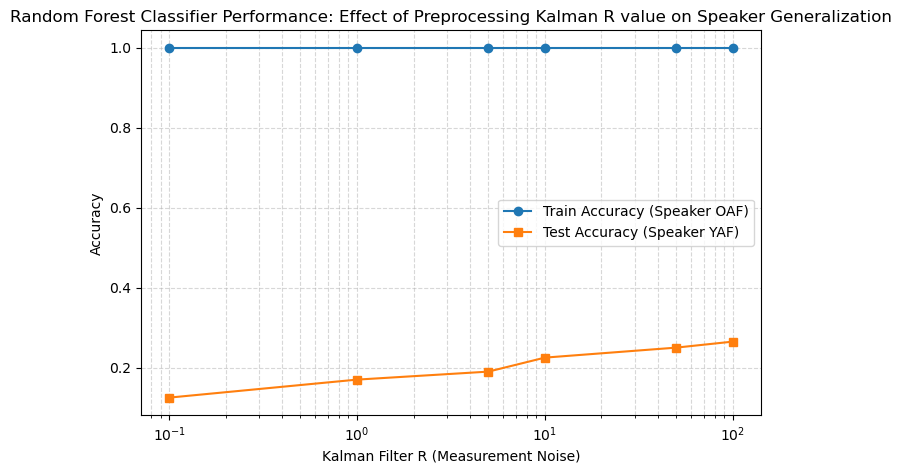

In [77]:
# Plot the Random Forest classifier performance vs R hyperparameter for generalization
plt.figure(figsize=(8,5))
plt.plot(r_values, train_accuracys_temporal, label='Train Accuracy (Speaker OAF)', marker='o')
plt.plot(r_values, test_accuracys_temporal, label='Test Accuracy (Speaker YAF)', marker='s')
plt.xscale('log')
plt.xlabel('Kalman Filter R (Measurement Noise)')
plt.ylabel('Accuracy')
plt.title('Random Forest Classifier Performance: Effect of Preprocessing Kalman R value on Speaker Generalization')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.show()

In [74]:
# Get the best R value
best_index = np.argmax(test_accuracys_temporal)
best_r = r_values[best_index]

print(f"The best Kalman R value on a subset of OAF data is {best_r} with YAF speaker generalization accuracy of {test_accuracys_temporal[best_index]:.3f}")

# Test a few different Random Forest Classifiers with varied hyperparameters: n_estimators, max_depth, min_samples_leaf

X_temporal = []

for path in tqdm(df['path']):
    X_temporal.append(extract_temporal_audio_with_r_features(path, best_r))
    
# Convert to numpy array
X_temporal = np.array(X_temporal)
# Split into train (OAF) and test (YAF)
X_train_temporal, y_train_temporal = X_temporal[train_idx], y[train_idx]
X_test_temporal, y_test_temporal = X_temporal[test_idx], y[test_idx]

# Scale the features
scaler_temporal = StandardScaler()
X_train_temporal_scaled = scaler.fit_transform(X_train_temporal)
X_test_temporal_scaled = scaler.transform(X_test_temporal)

# Train and evaluate Random Forest classifier #1: n_estimators = 200, max_depth=None, random_state=42
rf_1 = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_1.fit(X_train_temporal_scaled, y_train_temporal)

train_acc_1 = rf_1.score(X_train_temporal_scaled, y_train_temporal)
test_acc_1 = rf_1.score(X_test_temporal, y_test_temporal)
print(f"Training accuracy: {train_acc_1: .3f}, Testing accuracy: {test_acc_1: .3f} for R={r}, n_estimators=200, max_depth=None, random_state=42")

# Train and evaluate Random Forest classifier #2: n_estimators = 100, max_depth=10, random_state=42
rf_2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_2.fit(X_train_temporal_scaled, y_train_temporal)

train_acc_2 = rf_2.score(X_train_temporal_scaled, y_train_temporal)
test_acc_2 = rf_2.score(X_test_temporal, y_test_temporal)
print(f"Training accuracy: {train_acc_2: .3f}, Testing accuracy: {test_acc_2: .3f} for R={r}, n_estimators=100, max_depth=10, random_state=42")

# Train and evaluate Random Forest classifier #3: n_estimators=100, max_depth=5, min_samples_leaf=20, random_state=42
rf_3 = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=20, random_state=42)
rf_3.fit(X_train_temporal_scaled, y_train_temporal)

train_acc_3 = rf_3.score(X_train_temporal_scaled, y_train_temporal)
test_acc_3 = rf_3.score(X_test_temporal, y_test_temporal)
print(f"Training accuracy: {train_acc_3: .3f}, Testing accuracy: {test_acc_3: .3f} for R={r}, n_estimators=100, max_depth=5, min_samples_leaf=20, random_state=42")


The best Kalman R value on a subset of OAF data is 100 with YAF speaker generalization accuracy of 0.265


100%|██████████████████████████████████████████████████████████████████████| 2800/2800 [07:47<00:00,  5.99it/s]


Training accuracy:  1.000, Testing accuracy:  0.224 for R=100, n_estimators=200, max_depth=None, random_state=42
Training accuracy:  1.000, Testing accuracy:  0.181 for R=100, n_estimators=100, max_depth=10, random_state=42
Training accuracy:  0.988, Testing accuracy:  0.221 for R=100, n_estimators=100, max_depth=5, min_samples_leaf=20, random_state=42


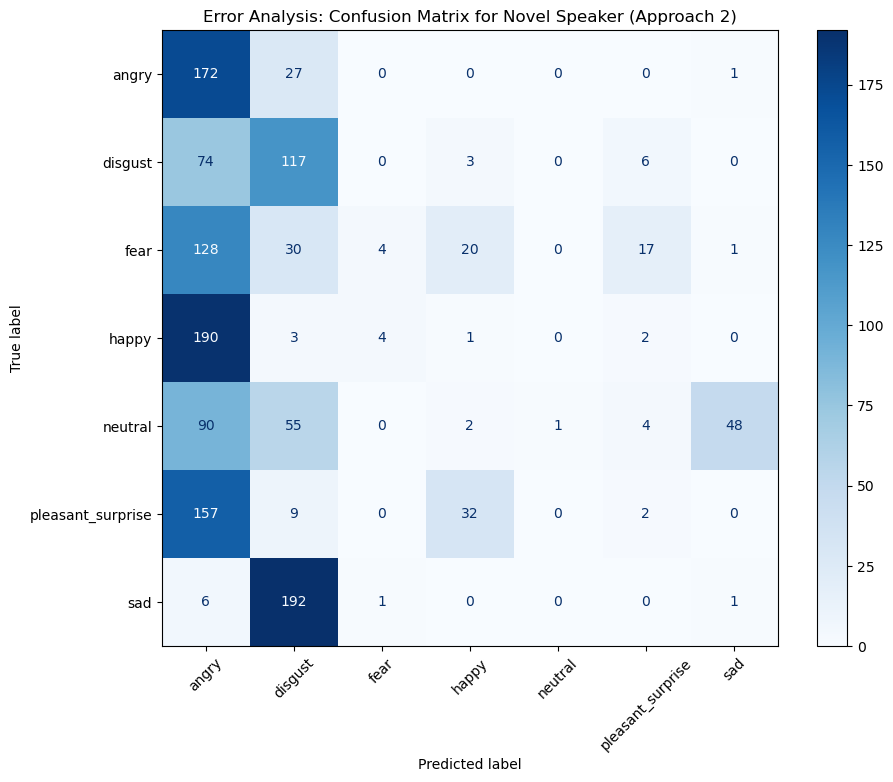

In [75]:
# Using the best hyperparameters 
y_pred_temporal = rf_3.predict(X_test_temporal_scaled)

# Plot the error analysis - confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_temporal, y_pred_temporal, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Error Analysis: Confusion Matrix for Novel Speaker (Approach 2)")
plt.show()

In [81]:
# Error Analysis: Total misclassified
misclassified_2 = np.where(y_test_temporal != y_pred_temporal)[0]
n_errors_2 = len(misclassified_2)
print(f"Total misclassified: {n_errors_2} out of {len(y_test_temporal)} ({n_errors_2/len(y_test_temporal) * 100: .3f}%)")

Total misclassified: 1102 out of 1400 ( 78.714%)


In [83]:
balanced_acc_temporal = balanced_accuracy_score(y_test_temporal, y_pred_temporal)
print(f"The test accuracy for a novel speaker is: {balanced_acc_temporal: .3f}")
print(f"The error rate on the test data for a novel speaker is: {1-(balanced_acc_temporal): .3f}")

print(f"The zero-one loss on the test data for a novel speaker is: {zero_one_loss(y_test_temporal, y_pred_temporal): .3f}")

The test accuracy for a novel speaker is:  0.213
The error rate on the test data for a novel speaker is:  0.787
The zero-one loss on the test data for a novel speaker is:  0.787


In [85]:
# Error analysis: classification report
print("Classification Report (Approach 2)")
print(classification_report(y_test_temporal, y_pred_temporal))

Classification Report (Approach 2)
                   precision    recall  f1-score   support

            angry       0.21      0.86      0.34       200
          disgust       0.27      0.58      0.37       200
             fear       0.44      0.02      0.04       200
            happy       0.02      0.01      0.01       200
          neutral       1.00      0.01      0.01       200
pleasant_surprise       0.06      0.01      0.02       200
              sad       0.02      0.01      0.01       200

         accuracy                           0.21      1400
        macro avg       0.29      0.21      0.11      1400
     weighted avg       0.29      0.21      0.11      1400



In [80]:
# Error Analysis: Feature importance
importances = rf_3.feature_importances_
print(f"Importance of MFCC Features: {np.sum(importances[:39]): .3f}")
print(f"Importance of Delta Features: {np.sum(importances[40:]): .3f}")

Importance of MFCC Features:  0.752
Importance of Delta Features:  0.247


## Approach 3: Kalman Smoothing of MFCCs & Deltas + Multi-Layer Perceptron

In [101]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu',               
    solver='adam',                   
    alpha=0.01,                      
    learning_rate_init=0.001,
    max_iter=500,                    
    random_state=42,
    early_stopping=True,             
    validation_fraction=0.1,
    verbose=True                     
)

# Train MLP using scaled data from Approach 2
mlp.fit(X_train_temporal_scaled, y_train_temporal)

# Evaluate the model
mlp_train_acc = mlp.score(X_train_temporal_scaled, y_train_temporal)
mlp_test_acc = mlp.score(X_test_temporal_scaled, y_test_temporal)

print(f"\nMLP Training Accuracy: {mlp_train_acc:.4f}")
print(f"MLP Testing Accuracy:  {mlp_test_acc:.4f}")

Iteration 1, loss = 1.71785870
Validation score: 0.735714
Iteration 2, loss = 1.13924851
Validation score: 0.900000
Iteration 3, loss = 0.70517616
Validation score: 0.921429
Iteration 4, loss = 0.40204912
Validation score: 0.950000
Iteration 5, loss = 0.22601499
Validation score: 0.985714
Iteration 6, loss = 0.13425827
Validation score: 0.985714
Iteration 7, loss = 0.08658066
Validation score: 0.985714
Iteration 8, loss = 0.06129232
Validation score: 0.985714
Iteration 9, loss = 0.04573543
Validation score: 0.985714
Iteration 10, loss = 0.03668181
Validation score: 0.992857
Iteration 11, loss = 0.03009221
Validation score: 0.985714
Iteration 12, loss = 0.02552432
Validation score: 0.992857
Iteration 13, loss = 0.02218178
Validation score: 0.992857
Iteration 14, loss = 0.01984154
Validation score: 0.992857
Iteration 15, loss = 0.01800289
Validation score: 0.992857
Iteration 16, loss = 0.01658240
Validation score: 0.992857
Iteration 17, loss = 0.01539226
Validation score: 0.992857
Iterat

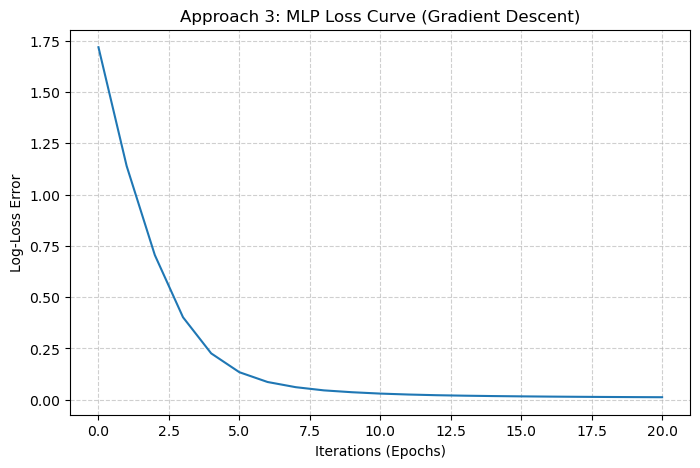

In [102]:
# Plot the MLP hyperparameter: number of iterations
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title('Approach 3: MLP Loss Curve (Gradient Descent)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Log-Loss Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

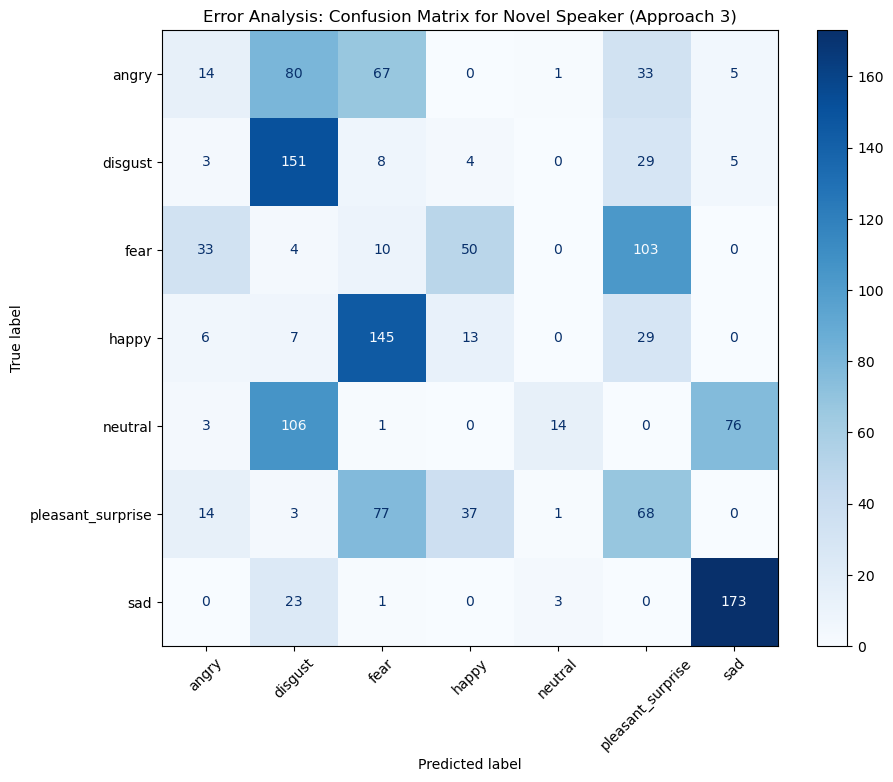

In [119]:
y_pred_temporal_mlp = mlp.predict(X_test_temporal_scaled)

# Plot the error analysis - confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_temporal, y_pred_temporal_mlp, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Error Analysis: Confusion Matrix for Novel Speaker (Approach 3)")
plt.show()

In [120]:
# Error Analysis: Total misclassified
misclassified_3 = np.where(y_test_temporal != y_pred_temporal_mlp)[0]
n_errors_3 = len(misclassified_3)
print(f"Total misclassified: {n_errors_3} out of {len(y_test_temporal)} ({n_errors_3/len(y_test_temporal) * 100: .3f}%)")

Total misclassified: 957 out of 1400 ( 68.357%)


In [121]:
balanced_acc_temporal_mlp = balanced_accuracy_score(y_test_temporal, y_pred_temporal_mlp)
print(f"The test accuracy for a novel speaker is: {balanced_acc_temporal_mlp: .3f}")
print(f"The error rate on the test data for a novel speaker is: {1-(balanced_acc_temporal_mlp): .3f}")

print(f"The zero-one loss on the test data for a novel speaker is: {zero_one_loss(y_test_temporal, y_pred_temporal_mlp): .3f}")

The test accuracy for a novel speaker is:  0.316
The error rate on the test data for a novel speaker is:  0.684
The zero-one loss on the test data for a novel speaker is:  0.684


In [122]:
# Error analysis: classification report
print("Classification Report (Approach 3)")
print(classification_report(y_test_temporal, y_pred_temporal_mlp))

Classification Report (Approach 3)
                   precision    recall  f1-score   support

            angry       0.19      0.07      0.10       200
          disgust       0.40      0.76      0.53       200
             fear       0.03      0.05      0.04       200
            happy       0.12      0.07      0.09       200
          neutral       0.74      0.07      0.13       200
pleasant_surprise       0.26      0.34      0.29       200
              sad       0.67      0.86      0.75       200

         accuracy                           0.32      1400
        macro avg       0.35      0.32      0.28      1400
     weighted avg       0.35      0.32      0.28      1400



## Approach 4: wav2vec 2.0 + Multi-Layer Perceptron

In [115]:
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor

# Load the processor and model
w2v = "facebook/wav2vec2-base-960h"
processor_w2v = Wav2Vec2Processor.from_pretrained(w2v)
model_w2v = Wav2Vec2Model.from_pretrained(w2v)

def extract_wav2vec_audio_features(file_path):
    # Load audio with sampling rate of 16kHz per wave2vec requirements
    speech, sr = librosa.load(file_path, sr=16000)
    
    # Preprocess to get tensors
    input_values = processor_w2v(speech, return_tensors="pt", sampling_rate=16000).input_values
    
    # Get the hidden state layers
    with torch.no_grad():
        outputs = model_w2v(input_values)
        
    # Use global average pooling along the temporal axis to transform embeddings into a single vector
    # Note: (1, sequence_length, 768) becomes (768,)
    embeddings = torch.mean(outputs.last_hidden_state, dim=1).squeeze()
    return embeddings.numpy() # convert the tensor into a numpy array and return

#Wav2vec feature extraction
X_w2v_features = []
for path in tqdm(df['path']):
    X_w2v_features.append(extract_wav2vec_audio_features(path))
    
# Convert to numpy array
X_w2v_features = np.array(X_w2v_features)


Loading weights: 100%|█████████████████████████████████████████████████████| 210/210 [00:00<00:00, 1804.25it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

  2%|█▋                                                                      | 64/2800 [00:13<13:53,  3.28it/s]


  7%|█████▏                                                                 | 206/2800 [00:53<12:44,  3.39it/s]


 12%|████████▊                                                              | 348/2800 [01:38<12:25,  3.29it/s]


 18%|████████████▍                                                          | 490/2800 [02:18<10:23,  3.71it/s]


 23%|████████████████                                                       | 632/2800 [02:58<09:50,  3.67it/s]


...

 83%|██████████████████████████████████████████████████████████▍           | 2336/2800 [10:53<02:12,  3.50it/s]


 88%|█████████████████████████████████████████████████████████████▉        | 2478/2800 [11:33<01:29,  3.60it/s]


 94%|█████████████████████████████████████████████████████████████████▌    | 2620/2800 [12:11<00:43,  4.17it/s]


 99%|█████████████████████████████████████████████████████████████████████ | 2762/2800 [12:47<00:09,  3.97it/s]


100%|██████████████████████████████████████████████████████████████████████| 2800/2800 [12:59<00:00,  3.59it/s]


In [117]:
# Split into train (oaf) and test (yaf)
X_train_w2v, y_train_w2v = X_w2v_features[train_idx], y[train_idx]
X_test_w2v, y_test_w2v = X_w2v_features[test_idx], y[test_idx]

# Scale the features
scaler_w2v = StandardScaler()
X_train_w2v_scaled = scaler_w2v.fit_transform(X_train_w2v)
X_test_w2v_scaled = scaler_w2v.transform(X_test_w2v)

# Initialize the MLP
w2v_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu',               
    solver='adam',                  
    alpha=0.01,                      
    learning_rate_init=0.001,
    max_iter=500,                    
    random_state=42,
    early_stopping=True,             
    validation_fraction=0.1,
    verbose=True                     
)

# Train the model
w2v_mlp.fit(X_train_w2v_scaled, y_train_w2v)

# Evaluate the model
w2v_mlp_train_acc = w2v_mlp.score(X_train_w2v_scaled, y_train_w2v)
w2v_mlp_test_acc = w2v_mlp.score(X_test_w2v_scaled, y_test_w2v)

print(f"MLP with Wav2Vec Feature Extraction Training Accuracy: {w2v_mlp_train_acc:.3f}")
print(f"MLP with Wav2Vec Feature Extraction Testing Accuracy:  {w2v_mlp_test_acc:.3f}")

Iteration 1, loss = 1.87976940
Validation score: 0.357143
Iteration 2, loss = 1.32348663
Validation score: 0.485714
Iteration 3, loss = 1.09213856
Validation score: 0.528571
Iteration 4, loss = 0.90519239
Validation score: 0.585714
Iteration 5, loss = 0.76575797
Validation score: 0.571429
Iteration 6, loss = 0.65544902
Validation score: 0.600000
Iteration 7, loss = 0.53950435
Validation score: 0.571429
Iteration 8, loss = 0.44649165
Validation score: 0.607143
Iteration 9, loss = 0.36513857
Validation score: 0.600000
Iteration 10, loss = 0.30441787
Validation score: 0.621429
Iteration 11, loss = 0.24928960
Validation score: 0.657143
Iteration 12, loss = 0.20676155
Validation score: 0.642857
Iteration 13, loss = 0.16445559
Validation score: 0.692857
Iteration 14, loss = 0.13602934
Validation score: 0.678571
Iteration 15, loss = 0.10655298
Validation score: 0.650000
Iteration 16, loss = 0.08970246
Validation score: 0.678571
Iteration 17, loss = 0.07071546
Validation score: 0.650000
Iterat

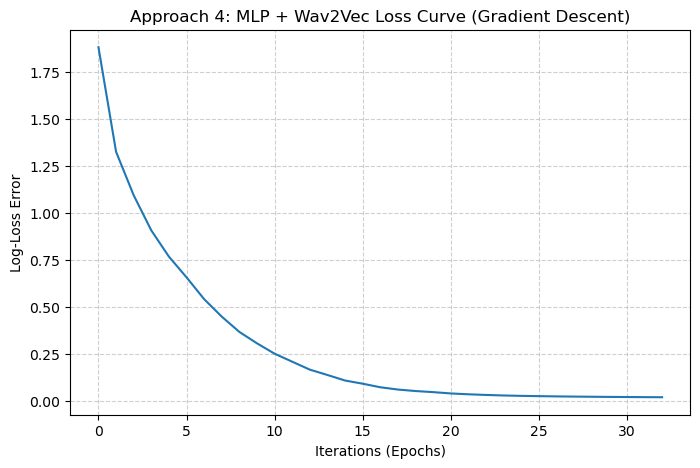

In [118]:
# Plot the MLP hyperparameter: number of iterations
plt.figure(figsize=(8, 5))
plt.plot(w2v_mlp.loss_curve_)
plt.title('Approach 4: MLP + Wav2Vec Loss Curve (Gradient Descent)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Log-Loss Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

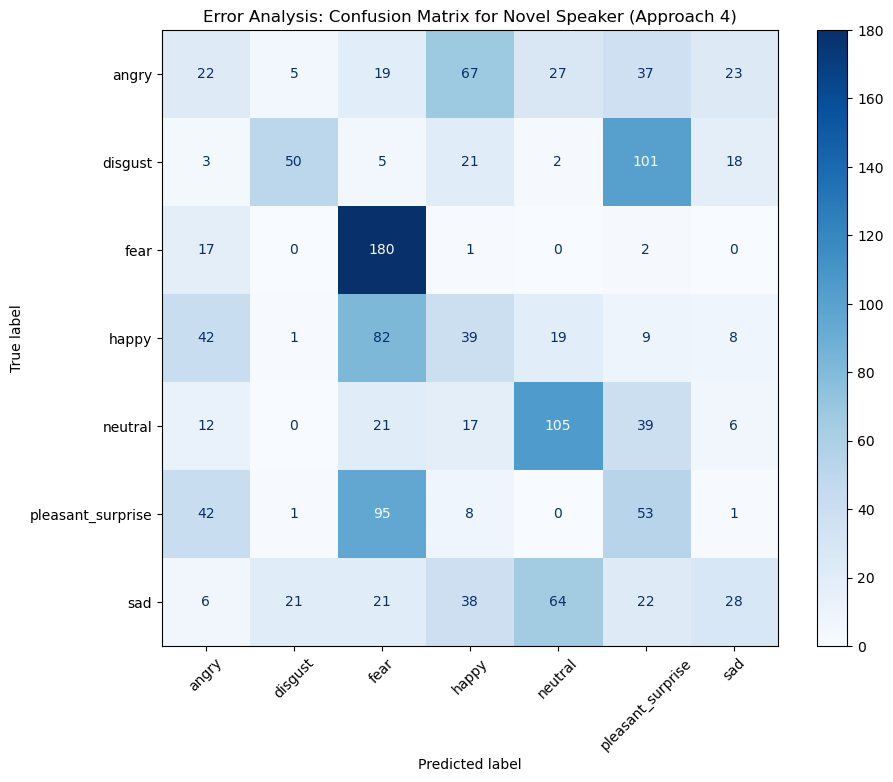

In [126]:
y_pred_mlp_w2v = w2v_mlp.predict(X_test_w2v_scaled)

# Plot the error analysis - confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_w2v, y_pred_mlp_w2v, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Error Analysis: Confusion Matrix for Novel Speaker (Approach 4)")
plt.show()

In [127]:
# Error Analysis: Total misclassified
misclassified_4 = np.where(y_test_w2v != y_pred_mlp_w2v)[0]
n_errors_4 = len(misclassified_4)
print(f"Total misclassified: {n_errors_4} out of {len(y_test_w2v)} ({n_errors_4/len(y_test_w2v) * 100: .3f}%)")

Total misclassified: 923 out of 1400 ( 65.929%)


In [129]:
balanced_acc_mlp_w2v = balanced_accuracy_score(y_test_w2v, y_pred_mlp_w2v)
print(f"The test accuracy for a novel speaker is: {balanced_acc_mlp_w2v: .3f}")
print(f"The error rate on the test data for a novel speaker is: {1-(balanced_acc_mlp_w2v): .3f}")

print(f"The zero-one loss on the test data for a novel speaker is: {zero_one_loss(y_test_w2v, y_pred_mlp_w2v): .3f}")

The test accuracy for a novel speaker is:  0.341
The error rate on the test data for a novel speaker is:  0.659
The zero-one loss on the test data for a novel speaker is:  0.659


In [130]:
# Error analysis: classification report
print("Classification Report (Approach 4)")
print(classification_report(y_test_w2v, y_pred_mlp_w2v))

Classification Report (Approach 4)
                   precision    recall  f1-score   support

            angry       0.15      0.11      0.13       200
          disgust       0.64      0.25      0.36       200
             fear       0.43      0.90      0.58       200
            happy       0.20      0.20      0.20       200
          neutral       0.48      0.53      0.50       200
pleasant_surprise       0.20      0.27      0.23       200
              sad       0.33      0.14      0.20       200

         accuracy                           0.34      1400
        macro avg       0.35      0.34      0.31      1400
     weighted avg       0.35      0.34      0.31      1400



## Approach 5: wav2vec 2.0 with Layer Extraction & Pyramid Pooling + Multi-Layer Perceptron

### Try 1: Extract Layer 8 only

In [25]:
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from tqdm import tqdm
import librosa

# Load the processor and model
w2v = "facebook/wav2vec2-base-960h"
processor_w2v = Wav2Vec2Processor.from_pretrained(w2v)
model_w2v = Wav2Vec2Model.from_pretrained(w2v)
model_w2v.config.output_hidden_states=True # enable to return hidden states
model_w2v.eval() # disable drop-outs so feature extraction uses wav2vec pre-trained speech

def extract_wav2vec_pyramid_audio_features(file_path):
    # Load audio with sampling rate of 16kHz per wave2vec requirements
    speech, sr = librosa.load(file_path, sr=16000)
    
    # Preprocess to get tensors
    input_values = processor_w2v(speech, return_tensors="pt", sampling_rate=16000).input_values
    
    # Get the hidden state layers
    with torch.no_grad():
        outputs = model_w2v(input_values)
        
    # Extract layer 8 and transforms (1, sequence_length, 768) into the 2D numpy array (sequence_length, 768)
    layer_8_features = outputs.hidden_states[8]
    embeddings = layer_8_features.squeeze(0).numpy()
    
    # Perform pyramid pooling - divide the wav2vec audio embeddings into increasing bucket sizes
    all_buckets = []
    for num_buckets in [1, 2, 4, 8]:
        # Split embeddings into num_buckets chunks row-wise (i.e. timestamps along the audio based on sequence_length)
        chunks = np.array_split(embeddings, num_buckets, axis=0)
        
        for chunk in chunks:
            if chunk.size > 0:
                mean_features = np.mean(chunk, axis=0)
                std_features = np.std(chunk, axis=0)
                all_buckets.append(mean_features)
                all_buckets.append(std_features)
            else:
                # handle empty buckets because mean and std returns NaN when performed on 0
                # Note: embeddings.shape consists of 768 feature width (columns) from wav2vec
                all_buckets.append(np.zeros(embeddings.shape[1]))
                all_buckets.append(np.zeros(embeddings.shape[1]))
                
    return np.concatenate(all_buckets, axis=0) # concatenate mean and std arrays in the all_buckets array as rows

# wav2vec feature extraction
X_w2v_pyramid_features = []
for path in tqdm(df['path']):
    X_w2v_pyramid_features.append(extract_wav2vec_pyramid_audio_features(path))
    
# Convert to numpy array
X_w2v_pyramid_features = np.array(X_w2v_pyramid_features)

Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 210/210 [00:00<00:00, 1700.09it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2800/2800 [13:57<00:00,  3.34it/s]


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Extract the output from the audio data
y = df['emotion'].values

# Create indices for the train/test split for generalization (train on OAF, test on YAF)
train_idx = df[df['speaker'] == 'oaf'].index
test_idx = df[df['speaker'] == 'yaf'].index

# Split into train (oaf) and test (yaf)
X_train_w2v_pyramid, y_train_w2v_pyramid = X_w2v_pyramid_features[train_idx], y[train_idx]
X_test_w2v_pyramid, y_test_w2v_pyramid = X_w2v_pyramid_features[test_idx], y[test_idx]

# Scale the features
scaler_w2v = StandardScaler()
X_train_w2v_pyramid_scaled = scaler_w2v.fit_transform(X_train_w2v_pyramid)
X_test_w2v_pyramid_scaled = scaler_w2v.transform(X_test_w2v_pyramid)

# Initialize the Multi-Layer Perceptron
w2v_pyramid_mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128), 
    activation='relu',               
    solver='adam',                   
    alpha=0.05,                      
    learning_rate_init=0.001,      
    n_iter_no_change=10,           
    random_state=42,
    early_stopping=True,            
    validation_fraction=0.1,
    verbose=True                     
)

# Train the model
w2v_pyramid_mlp.fit(X_train_w2v_pyramid_scaled, y_train_w2v_pyramid)

# Evaluate the model
w2v_pyramid_mlp_train_acc = w2v_pyramid_mlp.score(X_train_w2v_pyramid_scaled, y_train_w2v_pyramid)
w2v_pyramid_mlp_test_acc = w2v_pyramid_mlp.score(X_test_w2v_pyramid_scaled, y_test_w2v_pyramid)

print(f"MLP with Wav2Vec Feature Extraction Training Accuracy: {w2v_pyramid_mlp_train_acc:.3f}")
print(f"MLP with Wav2Vec Feature Extraction Testing Accuracy:  {w2v_pyramid_mlp_test_acc:.3f}")

Iteration 1, loss = 1.25020364
Validation score: 0.907143
Iteration 2, loss = 0.32626054
Validation score: 0.935714
Iteration 3, loss = 0.26333293
Validation score: 0.942857
Iteration 4, loss = 0.28165496
Validation score: 0.957143
Iteration 5, loss = 0.28286931
Validation score: 0.971429
Iteration 6, loss = 0.28517208
Validation score: 0.971429
Iteration 7, loss = 0.29027691
Validation score: 0.921429
Iteration 8, loss = 0.29330926
Validation score: 0.950000
Iteration 9, loss = 0.26835474
Validation score: 0.957143
Iteration 10, loss = 0.29281675
Validation score: 0.971429
Iteration 11, loss = 0.26689700
Validation score: 0.971429
Iteration 12, loss = 0.28571534
Validation score: 0.971429
Iteration 13, loss = 0.29500219
Validation score: 0.978571
Iteration 14, loss = 0.25786527
Validation score: 0.971429
Iteration 15, loss = 0.25748262
Validation score: 0.971429
Iteration 16, loss = 0.25453721
Validation score: 0.971429
Iteration 17, loss = 0.25200106
Validation score: 0.978571
Iterat

### Try 2: Extract Layers 6 and 8

In [35]:
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from tqdm import tqdm
import librosa

# Load the processor and model
w2v = "facebook/wav2vec2-base-960h"
processor_w2v = Wav2Vec2Processor.from_pretrained(w2v)
model_w2v = Wav2Vec2Model.from_pretrained(w2v)
model_w2v.config.output_hidden_states=True # enable to return hidden states
model_w2v.eval() # disable drop-outs so feature extraction uses wav2vec pre-trained speech

def extract_wav2vec_pyramid_audio_features(file_path):
    # Load audio with sampling rate of 16kHz per wave2vec requirements
    speech, sr = librosa.load(file_path, sr=16000)
    
    # Preprocess to get the tensors
    input_values = processor_w2v(speech, return_tensors="pt", sampling_rate=16000).input_values
    
    # Get the hidden state layers
    with torch.no_grad():
        outputs = model_w2v(input_values)
        
    # Extract layers 6 and 8; transform (1, sequence_length, 768) into the 2D numpy array (sequence_length, 768)
    layer_6 = outputs.hidden_states[6] #spectral/acoustic characteristics
    layer_8 = outputs.hidden_states[8] #prosodic/melodic characteristics
    layer_6_embeddings = layer_6.squeeze(0).numpy()
    layer_8_embeddings = layer_8.squeeze(0).numpy()
    
    # Perform pyramid pooling - divide the wav2vec audio embeddings into increasing bucket sizes
    all_buckets = []
    for e in [layer_6_embeddings, layer_8_embeddings]:
        for num_buckets in [1, 2, 4, 8]:
            # Split embeddings into num_buckets chunks row-wise (i.e. timestamps along the audio based on sequence_length)
            chunks = np.array_split(e, num_buckets, axis=0)

            for chunk in chunks:
                if chunk.size > 0:
                    mean_features = np.mean(chunk, axis=0)
                    std_features = np.std(chunk, axis=0)
                    all_buckets.append(mean_features)
                    all_buckets.append(std_features)
                else:
                    # handle empty buckets because mean and std returns NaN when performed on 0
                    # Note: embeddings.shape consists of 768 feature width (columns) from wav2vec
                    all_buckets.append(np.zeros(embeddings.shape[1]))
                    all_buckets.append(np.zeros(embeddings.shape[1]))
                
    return np.concatenate(all_buckets, axis=0) # concatenate mean and std arrays in the all_buckets array as rows

# wav2vec feature extraction
X_w2v_pyramid_features = []
for path in tqdm(df['path']):
    X_w2v_pyramid_features.append(extract_wav2vec_pyramid_audio_features(path))
    
# Convert to numpy array
X_w2v_pyramid_features = np.array(X_w2v_pyramid_features)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 210/210 [00:00<00:00, 987.25it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2800/2800 [13:43<00:00,  3.40it/s]


In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Extract the output from the audio data
y = df['emotion'].values

# Create indices for the train/test split for generalization
train_idx = df[df['speaker'] == 'oaf'].index
test_idx = df[df['speaker'] == 'yaf'].index

# Split into train (oaf) and test (yaf)
X_train_w2v_pyramid, y_train_w2v_pyramid = X_w2v_pyramid_features[train_idx], y[train_idx]
X_test_w2v_pyramid, y_test_w2v_pyramid = X_w2v_pyramid_features[test_idx], y[test_idx]

# Scale the features
scaler_w2v = StandardScaler()
X_train_w2v_pyramid_scaled = scaler_w2v.fit_transform(X_train_w2v_pyramid)
X_test_w2v_pyramid_scaled = scaler_w2v.transform(X_test_w2v_pyramid)

# Initialize the Multi-Layer Perceptron
w2v_pyramid_mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256), 
    activation='relu',               
    solver='adam',                   
    alpha=0.05,                     
    learning_rate_init=0.001,      
    n_iter_no_change=10,           
    random_state=42,
    early_stopping=True,            
    validation_fraction=0.1,
    verbose=True                     
)

# Train the model
w2v_pyramid_mlp.fit(X_train_w2v_pyramid_scaled, y_train_w2v_pyramid)

# Evaluate the model
w2v_pyramid_mlp_train_acc = w2v_pyramid_mlp.score(X_train_w2v_pyramid_scaled, y_train_w2v_pyramid)
w2v_pyramid_mlp_test_acc = w2v_pyramid_mlp.score(X_test_w2v_pyramid_scaled, y_test_w2v_pyramid)

print(f"MLP with Wav2Vec Feature Extraction Training Accuracy: {w2v_pyramid_mlp_train_acc:.3f}")
print(f"MLP with Wav2Vec Feature Extraction Testing Accuracy:  {w2v_pyramid_mlp_test_acc:.3f}")

Iteration 1, loss = 2.30863197
Validation score: 0.950000
Iteration 2, loss = 0.81624511
Validation score: 0.957143
Iteration 3, loss = 0.64718092
Validation score: 0.992857
Iteration 4, loss = 0.66977143
Validation score: 0.992857
Iteration 5, loss = 0.63527012
Validation score: 1.000000
Iteration 6, loss = 0.62320446
Validation score: 1.000000
Iteration 7, loss = 0.62455741
Validation score: 1.000000
Iteration 8, loss = 0.62239902
Validation score: 1.000000
Iteration 9, loss = 0.61779548
Validation score: 1.000000
Iteration 10, loss = 0.61175469
Validation score: 1.000000
Iteration 11, loss = 0.60487626
Validation score: 1.000000
Iteration 12, loss = 0.59747504
Validation score: 1.000000
Iteration 13, loss = 0.58973228
Validation score: 1.000000
Iteration 14, loss = 0.58175116
Validation score: 1.000000
Iteration 15, loss = 0.57359640
Validation score: 1.000000
Iteration 16, loss = 0.56530647
Validation score: 1.000000
Validation score did not improve more than tol=0.000100 for 10 co

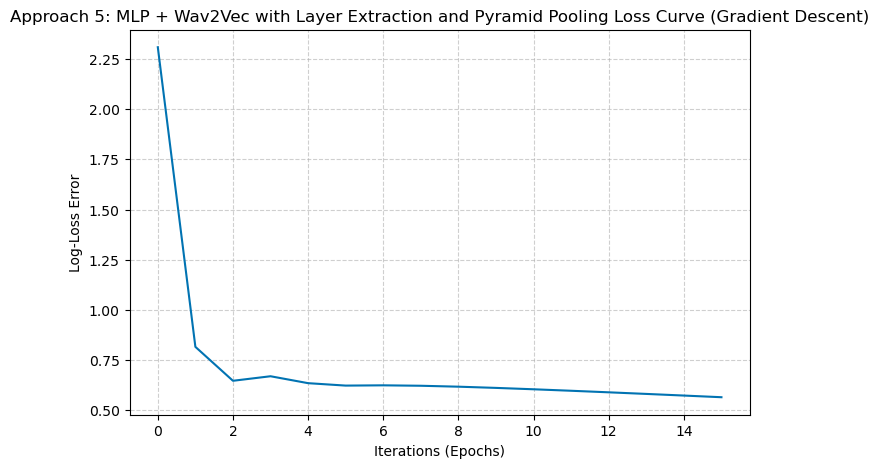

In [38]:
# Plot the MLP hyperparameter: number of iterations
plt.figure(figsize=(8, 5))
plt.plot(w2v_pyramid_mlp.loss_curve_)
plt.title('Approach 5: MLP + Wav2Vec with Layer Extraction and Pyramid Pooling Loss Curve (Gradient Descent)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Log-Loss Error')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

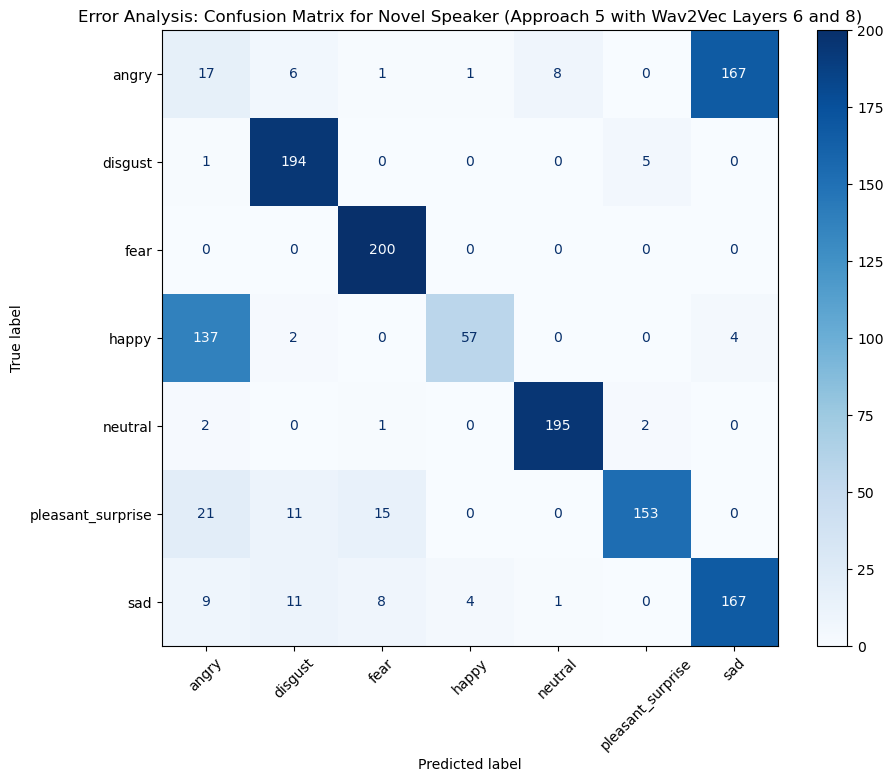

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_mlp_w2v_pyramid = w2v_pyramid_mlp.predict(X_test_w2v_pyramid_scaled)

# Plot the error analysis - confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_w2v_pyramid, y_pred_mlp_w2v_pyramid, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Error Analysis: Confusion Matrix for Novel Speaker (Approach 5 with Wav2Vec Layers 6 and 8)")
plt.show()

In [46]:
# Error Analysis: Total misclassified
misclassified_5 = np.where(y_test_w2v_pyramid != y_pred_mlp_w2v_pyramid)[0]
n_errors_5 = len(misclassified_5)
print(f"Total misclassified: {n_errors_5} out of {len(y_test_w2v_pyramid)} ({n_errors_5/len(y_test_w2v_pyramid) * 100: .3f}%)")

Total misclassified: 417 out of 1400 ( 29.786%)


In [48]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import zero_one_loss

balanced_acc_mlp_w2v_pyramid = balanced_accuracy_score(y_test_w2v_pyramid, y_pred_mlp_w2v_pyramid)
print(f"The test accuracy for a novel speaker is: {balanced_acc_mlp_w2v_pyramid: .3f}")
print(f"The error rate on the test data for a novel speaker is: {1-(balanced_acc_mlp_w2v_pyramid): .3f}")

print(f"The zero-one loss on the test data for a novel speaker is: {zero_one_loss(y_test_w2v_pyramid, y_pred_mlp_w2v_pyramid): .3f}")

The test accuracy for a novel speaker is:  0.702
The error rate on the test data for a novel speaker is:  0.298
The zero-one loss on the test data for a novel speaker is:  0.298


In [52]:
from sklearn.metrics import classification_report

# Error analysis: classification report
print("Classification Report (Approach 5)")
print(classification_report(y_test_w2v_pyramid, y_pred_mlp_w2v_pyramid))

Classification Report (Approach 5)
                   precision    recall  f1-score   support

            angry       0.09      0.09      0.09       200
          disgust       0.87      0.97      0.92       200
             fear       0.89      1.00      0.94       200
            happy       0.92      0.28      0.44       200
          neutral       0.96      0.97      0.97       200
pleasant_surprise       0.96      0.77      0.85       200
              sad       0.49      0.83      0.62       200

         accuracy                           0.70      1400
        macro avg       0.74      0.70      0.69      1400
     weighted avg       0.74      0.70      0.69      1400

